# Supply Chain & Inventory Analytics — Business Analysis

## Objective

This notebook analyzes demand, inventory health, replenishment risk,
supplier performance, SKU performance, warehouse performance,
regional performance, financial KPIs, and promotion-related demand.

The dataset has already been profiled and validated in:

`01_data_profiling.ipynb`

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

In [25]:
DATA_PATH = Path("../data/raw/supply_chain_dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}"
    )

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")

print(f"Dataset loaded: {len(df):,} records")

Dataset loaded: 91,250 records


In [26]:
required_columns = [
    "Date",
    "SKU_ID",
    "Warehouse_ID",
    "Supplier_ID",
    "Region",
    "Units_Sold",
    "Inventory_Level",
    "Supplier_Lead_Time_Days",
    "Reorder_Point",
    "Unit_Cost",
    "Unit_Price",
    "Promotion_Flag",
    "Stockout_Flag",
    "Demand_Forecast"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("Dataset validation passed.")

Dataset validation passed.


## 1. Feature Engineering

In [27]:
# Reorder risk
df["Below_Reorder_Point"] = (
    df["Inventory_Level"] < df["Reorder_Point"]
)

# Inventory gap
df["Inventory_Gap"] = (
    df["Reorder_Point"] - df["Inventory_Level"]
)

# Inventory coverage based on forecast demand
df["Inventory_Coverage_Days"] = (
    df["Inventory_Level"]
    / df["Demand_Forecast"].replace(0, np.nan)
)

# Coverage below supplier lead time
df["Coverage_Below_Lead_Time"] = (
    df["Inventory_Coverage_Days"]
    < df["Supplier_Lead_Time_Days"]
)

# Financial metrics
df["Inventory_Value"] = (
    df["Inventory_Level"]
    * df["Unit_Cost"]
)

df["Sales_Value"] = (
    df["Units_Sold"]
    * df["Unit_Price"]
)

df["COGS"] = (
    df["Units_Sold"]
    * df["Unit_Cost"]
)

df["Inventory_to_Demand_Ratio"] = (
    df["Inventory_Level"]
    / df["Units_Sold"].replace(0, np.nan)
)

print("Feature engineering completed.")

Feature engineering completed.


## 2. Executive KPI Summary

In [28]:
total_sales = df["Sales_Value"].sum()
total_cogs = df["COGS"].sum()
gross_profit = total_sales - total_cogs

gross_margin = (
    gross_profit / total_sales * 100
    if total_sales != 0
    else np.nan
)

executive_kpis = pd.DataFrame({
    "KPI": [
        "Total Records",
        "Total Units Sold",
        "Average Daily Demand",
        "Total Sales",
        "Total COGS",
        "Gross Profit",
        "Gross Margin",
        "Total Inventory Value",
        "Average Inventory Level",
        "Average Inventory Coverage",
        "Reorder Risk",
        "Stockout Records",
        "Average Supplier Lead Time"
    ],
    "Value": [
        len(df),
        df["Units_Sold"].sum(),
        df["Units_Sold"].mean(),
        total_sales,
        total_cogs,
        gross_profit,
        gross_margin,
        df["Inventory_Value"].sum(),
        df["Inventory_Level"].mean(),
        df["Inventory_Coverage_Days"].mean(),
        df["Below_Reorder_Point"].mean() * 100,
        df["Stockout_Flag"].sum(),
        df["Supplier_Lead_Time_Days"].mean()
    ]
})

display(executive_kpis)

,KPI,Value
0,Total Records,"91,250.00"
1,Total Units Sold,"1,829,979.00"
2,Average Daily Demand,20.05
3,Total Sales,"33,426,337.22"
4,Total COGS,"22,338,135.99"
5,Gross Profit,"11,088,201.23"
6,Gross Margin,33.17
7,Total Inventory Value,"525,243,991.12"
8,Average Inventory Level,471.52
9,Average Inventory Coverage,45.13


## 3. Inventory Health

In [29]:
inventory_summary = pd.DataFrame({
    "Metric": [
        "Average Inventory",
        "Median Inventory",
        "Minimum Inventory",
        "Maximum Inventory",
        "Average Reorder Point",
        "Median Reorder Point"
    ],
    "Value": [
        df["Inventory_Level"].mean(),
        df["Inventory_Level"].median(),
        df["Inventory_Level"].min(),
        df["Inventory_Level"].max(),
        df["Reorder_Point"].mean(),
        df["Reorder_Point"].median()
    ]
})

display(inventory_summary)

,Metric,Value
0,Average Inventory,471.52
1,Median Inventory,461.00
2,Minimum Inventory,168.00
3,Maximum Inventory,990.00
4,Average Reorder Point,300.07
5,Median Reorder Point,300.00


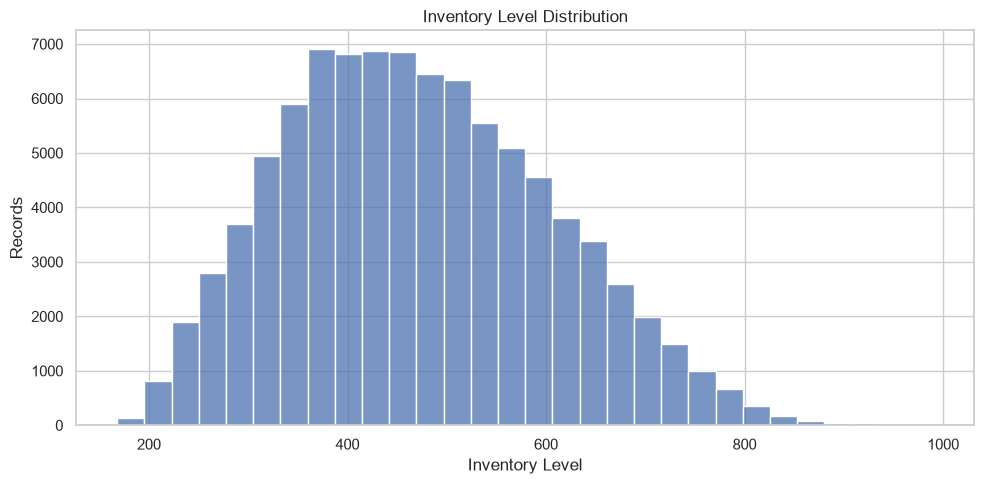

In [30]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Inventory_Level",
    bins=30
)

plt.title("Inventory Level Distribution")
plt.xlabel("Inventory Level")
plt.ylabel("Records")

plt.tight_layout()
plt.show()

## 4. Reorder Risk Analysis

In [31]:
reorder_risk = (
    df.groupby("Warehouse_ID")
    .agg(
        Records=("SKU_ID", "count"),
        Average_Inventory=("Inventory_Level", "mean"),
        Average_Reorder_Point=("Reorder_Point", "mean"),
        Reorder_Risk=("Below_Reorder_Point", "mean")
    )
    .reset_index()
)

reorder_risk["Reorder_Risk_%"] = (
    reorder_risk["Reorder_Risk"] * 100
)

reorder_risk = reorder_risk.drop(
    columns="Reorder_Risk"
)

reorder_risk = reorder_risk.sort_values(
    "Reorder_Risk_%",
    ascending=False
)

display(reorder_risk)

,Warehouse_ID,Records,Average_Inventory,Average_Reorder_Point,Reorder_Risk_%
4,WH_5,18250,467.12,299.00,5.30
2,WH_3,18250,455.56,284.96,5.28
0,WH_1,18250,466.06,292.12,5.24
1,WH_2,18250,491.49,318.88,5.23
3,WH_4,18250,477.39,305.38,5.18


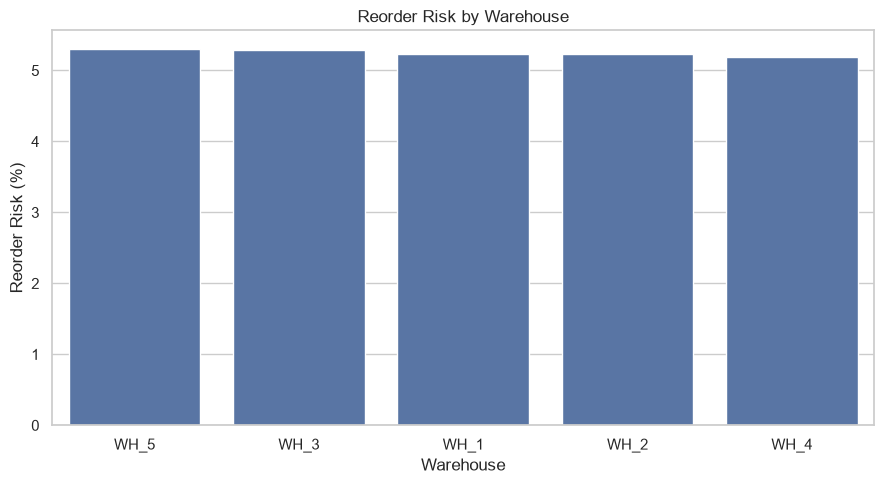

In [32]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=reorder_risk,
    x="Warehouse_ID",
    y="Reorder_Risk_%"
)

plt.title("Reorder Risk by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Reorder Risk (%)")

plt.tight_layout()
plt.show()

## 5. Replenishment Coverage Risk

In [33]:
coverage_risk = pd.DataFrame({
    "Metric": [
        "Risky Records",
        "Risk Percentage"
    ],
    "Value": [
        df["Coverage_Below_Lead_Time"].sum(),
        df["Coverage_Below_Lead_Time"].mean() * 100
    ]
})

display(coverage_risk)

,Metric,Value
0,Risky Records,"4,219.00"
1,Risk Percentage,4.62


In [34]:
warehouse_coverage = (
    df.groupby("Warehouse_ID")
    .agg(
        Records=("SKU_ID", "count"),
        Risky_Records=("Coverage_Below_Lead_Time", "sum"),
        Average_Coverage=("Inventory_Coverage_Days", "mean"),
        Average_Lead_Time=("Supplier_Lead_Time_Days", "mean")
    )
    .reset_index()
)

warehouse_coverage["Coverage_Risk_%"] = (
    warehouse_coverage["Risky_Records"]
    / warehouse_coverage["Records"]
    * 100
)

warehouse_coverage = warehouse_coverage.sort_values(
    "Coverage_Risk_%",
    ascending=False
)

display(warehouse_coverage)

,Warehouse_ID,Records,Risky_Records,Average_Coverage,Average_Lead_Time,Coverage_Risk_%
2,WH_3,18250,1016,45.14,8.22,5.57
3,WH_4,18250,994,42.67,8.48,5.45
0,WH_1,18250,872,44.13,8.00,4.78
1,WH_2,18250,764,50.65,8.46,4.19
4,WH_5,18250,573,43.09,6.76,3.14


## 6. Demand Analysis

In [35]:
demand_summary = pd.DataFrame({
    "Metric": [
        "Total Units Sold",
        "Average Daily Demand",
        "Median Daily Demand",
        "Minimum Daily Demand",
        "Maximum Daily Demand",
        "Demand Standard Deviation"
    ],
    "Value": [
        df["Units_Sold"].sum(),
        df["Units_Sold"].mean(),
        df["Units_Sold"].median(),
        df["Units_Sold"].min(),
        df["Units_Sold"].max(),
        df["Units_Sold"].std()
    ]
})

display(demand_summary)

,Metric,Value
0,Total Units Sold,"1,829,979.00"
1,Average Daily Demand,20.05
2,Median Daily Demand,20.00
3,Minimum Daily Demand,0.00
4,Maximum Daily Demand,59.00
5,Demand Standard Deviation,9.07


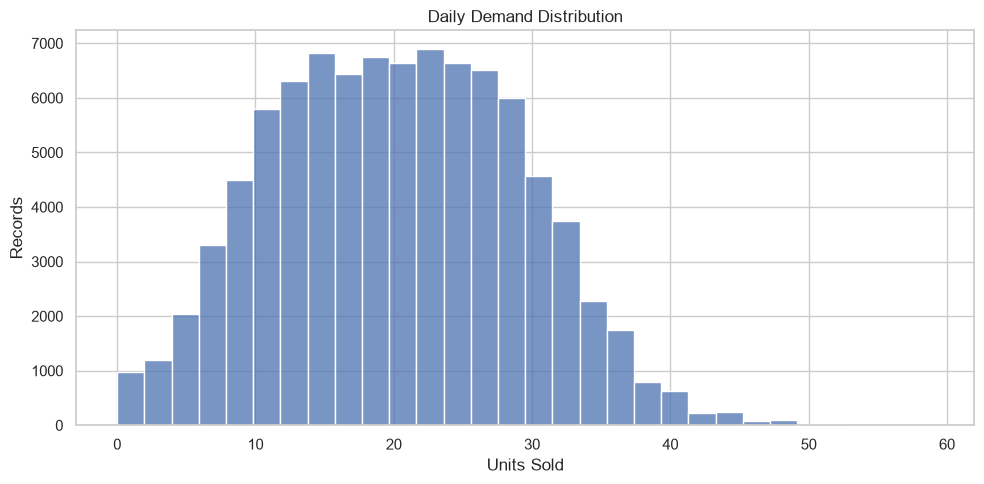

In [36]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Units_Sold",
    bins=30
)

plt.title("Daily Demand Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Records")

plt.tight_layout()
plt.show()

## 7. SKU Performance

In [37]:
sku_performance = (
    df.groupby("SKU_ID")
    .agg(
        Total_Units_Sold=("Units_Sold", "sum"),
        Average_Daily_Demand=("Units_Sold", "mean"),
        Demand_Std=("Units_Sold", "std"),
        Total_Sales=("Sales_Value", "sum"),
        Total_Inventory_Value=("Inventory_Value", "sum"),
        Average_Inventory=("Inventory_Level", "mean"),
        Reorder_Risk=("Below_Reorder_Point", "mean"),
        Average_Coverage=("Inventory_Coverage_Days", "mean")
    )
    .reset_index()
)

sku_performance["Reorder_Risk_%"] = (
    sku_performance["Reorder_Risk"] * 100
)

sku_performance = sku_performance.drop(
    columns="Reorder_Risk"
)

display(
    sku_performance.sort_values(
        "Total_Units_Sold",
        ascending=False
    ).head(10)
)

,SKU_ID,Total_Units_Sold,Average_Daily_Demand,Demand_Std,Total_Sales,Total_Inventory_Value,Average_Inventory,Average_Coverage,Reorder_Risk_%
9,SKU_18,37234,20.40,9.31,"644,766.53","10,184,572.45",463.70,36.57,5.15
0,SKU_1,37026,20.29,8.95,"617,298.40","11,084,810.67",514.68,40.13,5.04
26,SKU_33,37012,20.28,8.98,"673,070.84","10,402,775.24",481.92,36.95,5.21
4,SKU_13,36915,20.23,9.22,"720,991.94","12,504,434.27",485.85,42.54,5.10
41,SKU_47,36912,20.23,8.92,"538,811.71","9,035,680.22",514.67,44.47,4.93
49,SKU_9,36855,20.19,9.02,"593,421.66","9,901,916.08",487.49,41.35,5.32
33,SKU_4,36811,20.17,9.15,"770,679.65","11,924,966.98",470.57,38.29,5.26
3,SKU_12,36794,20.16,9.17,"582,012.28","10,132,231.82",466.36,41.45,5.32
22,SKU_3,36785,20.16,9.20,"668,701.09","9,236,415.25",443.61,71.67,5.37
24,SKU_31,36742,20.13,8.85,"827,241.09","12,692,518.80",465.24,44.00,5.10


## 8. Warehouse Performance

In [38]:
warehouse_performance = (
    df.groupby("Warehouse_ID")
    .agg(
        Total_Units_Sold=("Units_Sold", "sum"),
        Total_Sales=("Sales_Value", "sum"),
        Total_COGS=("COGS", "sum"),
        Total_Inventory_Value=("Inventory_Value", "sum"),
        Average_Inventory=("Inventory_Level", "mean"),
        Average_Coverage=("Inventory_Coverage_Days", "mean"),
        Reorder_Risk=("Below_Reorder_Point", "mean"),
        Stockout_Rate=("Stockout_Flag", "mean")
    )
    .reset_index()
)

warehouse_performance["Reorder_Risk_%"] = (
    warehouse_performance["Reorder_Risk"] * 100
)

warehouse_performance["Stockout_Rate_%"] = (
    warehouse_performance["Stockout_Rate"] * 100
)

warehouse_performance = warehouse_performance.drop(
    columns=["Reorder_Risk", "Stockout_Rate"]
)

display(
    warehouse_performance.sort_values(
        "Reorder_Risk_%",
        ascending=False
    )
)

,Warehouse_ID,Total_Units_Sold,Total_Sales,Total_COGS,Total_Inventory_Value,Average_Inventory,Average_Coverage,Reorder_Risk_%,Stockout_Rate_%
4,WH_5,365114,"6,936,392.83","4,535,334.89","106,927,856.97",467.12,43.09,5.30,0.00
2,WH_3,366110,"6,478,245.81","4,284,323.14","97,151,661.10",455.56,45.14,5.28,0.00
0,WH_1,366902,"6,269,758.79","4,259,982.62","98,662,156.36",466.06,44.13,5.24,0.00
1,WH_2,366078,"7,395,653.40","4,990,280.67","121,398,875.91",491.49,50.65,5.23,0.00
3,WH_4,365775,"6,346,286.39","4,268,214.67","101,103,440.78",477.39,42.67,5.18,0.00


## 9. Supplier Performance

In [39]:
supplier_performance = (
    df.groupby("Supplier_ID")
    .agg(
        Records=("SKU_ID", "count"),
        Average_Lead_Time=("Supplier_Lead_Time_Days", "mean"),
        Total_Units_Sold=("Units_Sold", "sum"),
        Average_Demand=("Units_Sold", "mean"),
        Average_Inventory=("Inventory_Level", "mean"),
        Average_Reorder_Point=("Reorder_Point", "mean"),
        Reorder_Risk=("Below_Reorder_Point", "mean"),
        Stockout_Rate=("Stockout_Flag", "mean")
    )
    .reset_index()
)

supplier_performance["Reorder_Risk_%"] = (
    supplier_performance["Reorder_Risk"] * 100
)

supplier_performance["Stockout_Rate_%"] = (
    supplier_performance["Stockout_Rate"] * 100
)

supplier_performance = supplier_performance.drop(
    columns=["Reorder_Risk", "Stockout_Rate"]
)

display(
    supplier_performance.sort_values(
        "Reorder_Risk_%",
        ascending=False
    )
)

,Supplier_ID,Records,Average_Lead_Time,Total_Units_Sold,Average_Demand,Average_Inventory,Average_Reorder_Point,Reorder_Risk_%,Stockout_Rate_%
8,SUP_8,10220,8.50,205407,20.10,468.98,300.57,5.31,0.00
1,SUP_10,9855,7.41,197242,20.01,472.66,301.63,5.29,0.00
2,SUP_2,9490,8.42,190999,20.13,464.43,292.62,5.28,0.00
4,SUP_4,9125,8.64,183147,20.07,472.92,300.88,5.27,0.00
3,SUP_3,8395,8.26,168017,20.01,456.39,285.26,5.27,0.00
6,SUP_6,7300,7.90,146684,20.09,474.61,303.55,5.25,0.00
9,SUP_9,5840,8.19,117259,20.08,464.15,291.81,5.21,0.00
7,SUP_7,12410,7.56,248830,20.05,494.26,322.35,5.21,0.00
0,SUP_1,10220,8.11,204249,19.99,464.69,293.29,5.20,0.00
5,SUP_5,8395,6.96,168145,20.03,472.05,298.00,5.18,0.00


In [40]:
average_lead_time = (
    supplier_performance["Average_Lead_Time"].mean()
)

average_supplier_risk = (
    supplier_performance["Reorder_Risk_%"].mean()
)

supplier_performance["Priority_Flag"] = (
    (supplier_performance["Average_Lead_Time"] > average_lead_time)
    &
    (supplier_performance["Reorder_Risk_%"] > average_supplier_risk)
)

display(
    supplier_performance[
        supplier_performance["Priority_Flag"]
    ]
)

,Supplier_ID,Records,Average_Lead_Time,Total_Units_Sold,Average_Demand,Average_Inventory,Average_Reorder_Point,Reorder_Risk_%,Stockout_Rate_%,Priority_Flag
2,SUP_2,9490,8.42,190999,20.13,464.43,292.62,5.28,0.00,True
3,SUP_3,8395,8.26,168017,20.01,456.39,285.26,5.27,0.00,True
4,SUP_4,9125,8.64,183147,20.07,472.92,300.88,5.27,0.00,True
8,SUP_8,10220,8.50,205407,20.10,468.98,300.57,5.31,0.00,True


## 10. Regional Performance

In [41]:
regional_performance = (
    df.groupby("Region")
    .agg(
        Total_Units_Sold=("Units_Sold", "sum"),
        Total_Sales=("Sales_Value", "sum"),
        Total_COGS=("COGS", "sum"),
        Total_Inventory_Value=("Inventory_Value", "sum"),
        Average_Inventory=("Inventory_Level", "mean"),
        Reorder_Risk=("Below_Reorder_Point", "mean"),
        Average_Coverage=("Inventory_Coverage_Days", "mean")
    )
    .reset_index()
)

regional_performance["Reorder_Risk_%"] = (
    regional_performance["Reorder_Risk"] * 100
)

regional_performance = regional_performance.drop(
    columns="Reorder_Risk"
)

display(
    regional_performance.sort_values(
        "Total_Sales",
        ascending=False
    )
)

,Region,Total_Units_Sold,Total_Sales,Total_COGS,Total_Inventory_Value,Average_Inventory,Average_Coverage,Reorder_Risk_%
1,North,459849,"8,411,171.01","5,622,773.74","132,148,966.31",470.79,45.91,5.46
0,East,459961,"8,398,382.40","5,608,858.39","132,122,398.00",473.05,43.92,5.01
2,South,456954,"8,320,450.82","5,558,162.63","130,569,498.93",472.16,45.67,5.11
3,West,453215,"8,296,332.99","5,548,341.23","130,403,127.88",470.09,45.04,5.41


## 11. Promotion Analysis

In [42]:
promotion_analysis = (
    df.groupby("Promotion_Flag")
    .agg(
        Records=("Units_Sold", "count"),
        Total_Units_Sold=("Units_Sold", "sum"),
        Average_Units_Sold=("Units_Sold", "mean"),
        Demand_Std=("Units_Sold", "std")
    )
    .reset_index()
)

display(promotion_analysis)

,Promotion_Flag,Records,Total_Units_Sold,Average_Units_Sold,Demand_Std
0,0,81980,1599018,19.50,8.61
1,1,9270,230961,24.91,11.31


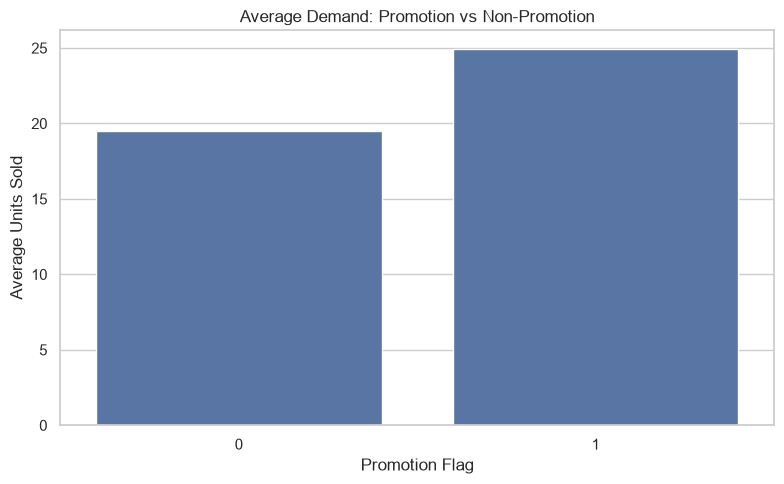

In [43]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=promotion_analysis,
    x="Promotion_Flag",
    y="Average_Units_Sold"
)

plt.title("Average Demand: Promotion vs Non-Promotion")
plt.xlabel("Promotion Flag")
plt.ylabel("Average Units Sold")

plt.tight_layout()
plt.show()

## 12. Inventory Efficiency & Overstock Screening

In [44]:
inventory_efficiency = (
    df.groupby("SKU_ID")
    .agg(
        Average_Inventory=("Inventory_Level", "mean"),
        Average_Daily_Demand=("Units_Sold", "mean"),
        Average_Coverage=("Inventory_Coverage_Days", "mean"),
        Average_Reorder_Point=("Reorder_Point", "mean"),
        Total_Units_Sold=("Units_Sold", "sum"),
        Total_Inventory_Value=("Inventory_Value", "sum")
    )
    .reset_index()
)

OVERSTOCK_COVERAGE_DAYS = 30

inventory_efficiency["Potential_Overstock"] = (
    inventory_efficiency["Average_Coverage"]
    > OVERSTOCK_COVERAGE_DAYS
)

display(
    inventory_efficiency.sort_values(
        "Average_Coverage",
        ascending=False
    ).head(10)
)

,SKU_ID,Average_Inventory,Average_Daily_Demand,Average_Coverage,Average_Reorder_Point,Total_Units_Sold,Total_Inventory_Value,Potential_Overstock
44,SKU_5,457.35,19.98,97.98,292.60,36457,"8,429,994.34",True
47,SKU_7,494.56,19.98,76.24,325.20,36462,"9,425,942.62",True
22,SKU_3,443.61,20.16,71.67,273.40,36785,"9,236,415.25",True
2,SKU_11,500.06,19.92,65.55,317.80,36358,"13,662,728.38",True
1,SKU_10,459.18,20.04,62.51,292.60,36579,"11,679,522.16",True
36,SKU_42,485.34,20.08,61.50,316.00,36637,"8,748,259.28",True
48,SKU_8,471.21,20.11,56.73,299.80,36702,"11,539,554.68",True
11,SKU_2,471.32,19.99,52.99,296.20,36490,"10,826,773.75",True
39,SKU_45,440.82,19.92,51.56,271.20,36347,"8,946,441.20",True
8,SKU_17,490.64,19.97,51.04,328.20,36449,"11,654,537.14",True


## 13. Financial Analysis

In [45]:
financial_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total COGS",
        "Gross Profit",
        "Gross Margin",
        "Total Inventory Value"
    ],
    "Value": [
        total_sales,
        total_cogs,
        gross_profit,
        gross_margin,
        df["Inventory_Value"].sum()
    ]
})

display(financial_summary)

,Metric,Value
0,Total Sales,"33,426,337.22"
1,Total COGS,"22,338,135.99"
2,Gross Profit,"11,088,201.23"
3,Gross Margin,33.17
4,Total Inventory Value,"525,243,991.12"


## 14. Business Priorities

In [46]:
highest_risk_warehouse = (
    warehouse_performance
    .sort_values("Reorder_Risk_%", ascending=False)
    .iloc[0]
)

highest_risk_sku = (
    sku_performance
    .sort_values("Reorder_Risk_%", ascending=False)
    .iloc[0]
)

highest_risk_supplier = (
    supplier_performance
    .sort_values("Reorder_Risk_%", ascending=False)
    .iloc[0]
)

highest_risk_region = (
    regional_performance
    .sort_values("Reorder_Risk_%", ascending=False)
    .iloc[0]
)

longest_lead_time_supplier = (
    supplier_performance
    .sort_values("Average_Lead_Time", ascending=False)
    .iloc[0]
)

print("KEY BUSINESS PRIORITIES")
print("=" * 50)

print(
    f"Highest warehouse reorder risk: "
    f"{highest_risk_warehouse['Warehouse_ID']} "
    f"({highest_risk_warehouse['Reorder_Risk_%']:.2f}%)"
)

print(
    f"Highest SKU reorder risk: "
    f"{highest_risk_sku['SKU_ID']} "
    f"({highest_risk_sku['Reorder_Risk_%']:.2f}%)"
)

print(
    f"Highest supplier reorder risk: "
    f"{highest_risk_supplier['Supplier_ID']} "
    f"({highest_risk_supplier['Reorder_Risk_%']:.2f}%)"
)

print(
    f"Highest regional reorder risk: "
    f"{highest_risk_region['Region']} "
    f"({highest_risk_region['Reorder_Risk_%']:.2f}%)"
)

print(
    f"Longest supplier lead time: "
    f"{longest_lead_time_supplier['Supplier_ID']} "
    f"({longest_lead_time_supplier['Average_Lead_Time']:.2f} days)"
)

KEY BUSINESS PRIORITIES
Highest warehouse reorder risk: WH_5 (5.30%)
Highest SKU reorder risk: SKU_14 (5.75%)
Highest supplier reorder risk: SUP_8 (5.31%)
Highest regional reorder risk: North (5.46%)
Longest supplier lead time: SUP_4 (8.64 days)


## 15. Business Recommendations

Based on the observed patterns:

1. Review reorder-point policies for high-risk inventory segments.
2. Monitor suppliers with relatively high lead times and reorder risk.
3. Prioritize warehouses with higher replenishment risk.
4. Use demand patterns when planning replenishment.
5. Investigate unusually high inventory coverage for potential overstock.

These recommendations are analytical starting points and should be validated
against actual business policies before operational implementation.

## 16. Final Summary

In [47]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Units Sold",
        "Average Daily Demand",
        "Total Sales",
        "Gross Profit",
        "Gross Margin",
        "Reorder Risk Rate",
        "Average Supplier Lead Time",
        "Average Inventory Coverage",
        "Potential Overstock Rate",
        "Number of SKUs",
        "Number of Warehouses",
        "Number of Suppliers",
        "Number of Regions"
    ],
    "Value": [
        len(df),
        df["Units_Sold"].sum(),
        df["Units_Sold"].mean(),
        total_sales,
        gross_profit,
        gross_margin,
        df["Below_Reorder_Point"].mean() * 100,
        df["Supplier_Lead_Time_Days"].mean(),
        df["Inventory_Coverage_Days"].mean(),
        inventory_efficiency["Potential_Overstock"].mean() * 100,
        df["SKU_ID"].nunique(),
        df["Warehouse_ID"].nunique(),
        df["Supplier_ID"].nunique(),
        df["Region"].nunique()
    ]
})

display(final_summary)

,Metric,Value
0,Total Records,"91,250.00"
1,Total Units Sold,"1,829,979.00"
2,Average Daily Demand,20.05
3,Total Sales,"33,426,337.22"
4,Gross Profit,"11,088,201.23"
5,Gross Margin,33.17
6,Reorder Risk Rate,5.25
7,Average Supplier Lead Time,7.98
8,Average Inventory Coverage,45.13
9,Potential Overstock Rate,100.00


## Conclusion

The analysis identifies the major demand, inventory, supplier, warehouse,
regional, and financial patterns in the dataset.

The resulting KPIs and business priorities form the analytical foundation
for the PostgreSQL SQL layer and future Power BI reporting.